# MIQR-CC - Pipeline 4 classes com RegNetY-8GF



In [2]:
import os
import json
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation


In [3]:
# ===== CONFIGURAÇÃO PRINCIPAL =====
DATA_ROOT = Path('/mounts/mecd-ap-g5/data')
DATASET_DIR = DATA_ROOT / 'MIQR-CC-Dataset'
PROCESSED_IMAGES_DIR = DATASET_DIR / 'processed'
METADATA_PATH = DATASET_DIR / 'metadata.csv'

NOTEBOOK_NAME = 'regnety8gf_4class'
RESULTS_DIR = Path('/mounts/mecd-ap-g5/results') / NOTEBOOK_NAME
MODELS_DIR = Path('/mounts/mecd-ap-g5/models') / NOTEBOOK_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Hiperparâmetros
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 4
EPOCHS = 20
PATIENCE = 5
LR_BACKBONE = 1e-5
LR_HEAD = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
BASELINE_MACRO_F1 = 0.738

print('Metadata:', METADATA_PATH)
print('Images:', PROCESSED_IMAGES_DIR)
print('Results:', RESULTS_DIR)
print('Models:', MODELS_DIR)

Metadata: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/metadata.csv
Images: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/processed
Results: /mounts/mecd-ap-g5/results/regnety8gf_4class
Models: /mounts/mecd-ap-g5/models/regnety8gf_4class


In [4]:
df = pd.read_csv(METADATA_PATH)
print('Shape original:', df.shape)
display(df.head())
print(df.columns.tolist())

Shape original: (19317, 12)


,raw_image_path,processed_image_path,patient_id,image_type,sex,birth_date,exam_date,exam_time,age,equipment_model,Label,Keep
0,raw/1_image1.png,processed/1_image1.png,1,S,M,22/08/1952,03/02/2022,11:50:32,69.0,Ziehm Vision RFD,Unlabelled,Keep
1,raw/1_image2.png,processed/1_image2.png,1,S,M,22/08/1952,03/02/2022,11:47:43,69.0,Ziehm Vision RFD,Unlabelled,Keep
2,raw/1_image3.png,processed/1_image3.png,1,S,M,22/08/1952,03/02/2022,12:08:45,69.0,Ziehm Vision RFD,Unlabelled,Keep
3,raw/1_image4.png,processed/1_image4.png,1,S,M,22/08/1952,03/02/2022,11:50:22,69.0,Ziehm Vision RFD,Unlabelled,Keep
4,raw/2_image5.png,processed/2_image5.png,2,S,F,15/08/1925,21/06/2022,20:09:00,96.0,Ziehm Vision RFD,Lithiasis,Discard


['raw_image_path', 'processed_image_path', 'patient_id', 'image_type', 'sex', 'birth_date', 'exam_date', 'exam_time', 'age', 'equipment_model', 'Label', 'Keep']


In [5]:
# Filtrar imagens marcadas como Keep e remover não etiquetadas
EXCLUDED_LABELS = {'unlabeled', 'unlabelled', 'unlabbeled', 'nan', ''}

label_col = 'Label'
if label_col not in df.columns:
    raise ValueError(f'Não encontrei a coluna {label_col!r}. Colunas disponíveis: {df.columns.tolist()}')

if 'Keep' in df.columns:
    keep_mask = df['Keep'].astype(str).str.strip().str.lower().eq('keep')
else:
    print('Aviso: coluna Keep não encontrada. Vou usar todas as linhas.')
    keep_mask = pd.Series(True, index=df.index)

raw_label = df[label_col].astype(str).str.strip()
label_mask = ~raw_label.str.lower().isin(EXCLUDED_LABELS)

df = df[keep_mask & label_mask].copy()

# Mapeamento para 4 classes
label_map = {
    'Benign Stricture': 'Stricture',
    'Malignant Stricture': 'Stricture',
    'Stricture': 'Stricture',
    'Biliary Leaks': 'Biliary Leaks',
    'Biliary_Leaks': 'Biliary Leaks',
    'Lithiasis': 'Lithiasis',
    'Normal': 'Normal',
}

df['label_4class'] = df[label_col].map(lambda x: label_map.get(str(x).strip(), None))
df = df[df['label_4class'].notna()].copy()

CLASS_NAMES = ['Biliary Leaks', 'Lithiasis', 'Stricture', 'Normal']
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df['target'] = df['label_4class'].map(class_to_idx)

print('Shape após filtro:', df.shape)
print('Distribuição 4 classes:')
print(df['label_4class'].value_counts())
print('Distribuição original depois do filtro:')
print(df[label_col].value_counts())

Shape após filtro: (1568, 14)
Distribuição 4 classes:
label_4class
Lithiasis        726
Stricture        392
Normal           299
Biliary Leaks    151
Name: count, dtype: int64
Distribuição original depois do filtro:
Label
Lithiasis              726
Malignant Stricture    329
Normal                 299
Biliary Leaks          151
Benign Stricture        63
Name: count, dtype: int64


In [6]:
# Resolver caminhos das imagens de forma robusta
candidate_path_cols = [
    'processed_image_path', 'image_path', 'Image_Path', 'path', 'filepath',
    'filename', 'file_name', 'image', 'Image'
]
path_col = next((c for c in candidate_path_cols if c in df.columns), None)
if path_col is None:
    raise ValueError(f'Não encontrei uma coluna de caminho. Colunas disponíveis: {df.columns.tolist()}')
print('Coluna de caminho usada:', path_col)

def resolve_image_path(value):
    p = Path(str(value))
    candidates = []
    if p.is_absolute():
        candidates.append(p)
    else:
        candidates.extend([
            DATASET_DIR / p,
            PROCESSED_IMAGES_DIR / p,
            PROCESSED_IMAGES_DIR / p.name,
            DATA_ROOT / p,
        ])
    for c in candidates:
        if c.exists():
            return str(c)
    return str(candidates[0]) if candidates else str(p)

df['resolved_path'] = df[path_col].apply(resolve_image_path)
df['exists'] = df['resolved_path'].apply(lambda p: Path(p).exists())
print('Imagens existentes:', df['exists'].sum(), '/', len(df))
if df['exists'].sum() < len(df):
    print('Exemplos sem ficheiro:')
    display(df.loc[~df['exists'], [path_col, 'resolved_path']].head())

df = df[df['exists']].reset_index(drop=True)
print('Shape final com ficheiros existentes:', df.shape)

Coluna de caminho usada: processed_image_path
Imagens existentes: 1568 / 1568
Shape final com ficheiros existentes: (1568, 16)


In [7]:
# Tentar detetar coluna de paciente/grupo
candidate_group_cols = [
    'patient_id', 'Patient_ID', 'patient', 'Patient', 'case_id', 'Case_ID',
    'exam_id', 'Exam_ID', 'study_id', 'StudyInstanceUID'
]
group_col = next((c for c in candidate_group_cols if c in df.columns), None)

if group_col is None:
    print('Aviso: não encontrei coluna de paciente. Vou criar grupos a partir do nome do ficheiro.')
    # Fallback: prefixo antes do primeiro separador comum
    df['group_id'] = df['resolved_path'].apply(lambda p: Path(p).stem.split('_')[0].split('-')[0])
    group_col = 'group_id'
else:
    print('Coluna de grupo usada:', group_col)

print('N grupos:', df[group_col].nunique())

Coluna de grupo usada: patient_id
N grupos: 436


In [8]:
# Split 70/15/15 com GroupShuffleSplit
# 1) treino vs temporário
split1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(split1.split(df, df['target'], groups=df[group_col]))
train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

# 2) validação vs teste
split2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel_idx, test_rel_idx = next(split2.split(temp_df, temp_df['target'], groups=temp_df[group_col]))
val_df = temp_df.iloc[val_rel_idx].copy()
test_df = temp_df.iloc[test_rel_idx].copy()

for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'{name}: {len(part)} imagens, {part[group_col].nunique()} grupos')
    print(part['label_4class'].value_counts())

# Guardar splits para reprodutibilidade
train_df.to_csv(RESULTS_DIR / 'split_train.csv', index=False)
val_df.to_csv(RESULTS_DIR / 'split_val.csv', index=False)
test_df.to_csv(RESULTS_DIR / 'split_test.csv', index=False)

train: 1088 imagens, 305 grupos
label_4class
Lithiasis        517
Stricture        270
Normal           212
Biliary Leaks     89
Name: count, dtype: int64
val: 268 imagens, 65 grupos
label_4class
Lithiasis        113
Stricture         54
Normal            51
Biliary Leaks     50
Name: count, dtype: int64
test: 212 imagens, 66 grupos
label_4class
Lithiasis        96
Stricture        68
Normal           36
Biliary Leaks    12
Name: count, dtype: int64


In [9]:
# Normalização ImageNet, adequada para pesos pré-treinados
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.12, contrast=0.18),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ERCPDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        img = Image.open(row['resolved_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        y = int(row['target'])
        return img, y, row['resolved_path']

train_ds = ERCPDataset(train_df, train_tfms)
val_ds = ERCPDataset(val_df, eval_tfms)
test_ds = ERCPDataset(test_df, eval_tfms)

# WeightedRandomSampler para ajudar no desbalanceamento
train_targets = train_df['target'].values
class_counts = np.bincount(train_targets, minlength=len(CLASS_NAMES))
class_weights_np = len(train_targets) / (len(CLASS_NAMES) * np.maximum(class_counts, 1))
sample_weights = class_weights_np[train_targets]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)
print('Class counts:', dict(zip(CLASS_NAMES, class_counts)))
print('Class weights:', dict(zip(CLASS_NAMES, class_weights_np.round(3))))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

Class counts: {'Biliary Leaks': np.int64(89), 'Lithiasis': np.int64(517), 'Stricture': np.int64(270), 'Normal': np.int64(212)}
Class weights: {'Biliary Leaks': np.float64(3.056), 'Lithiasis': np.float64(0.526), 'Stricture': np.float64(1.007), 'Normal': np.float64(1.283)}


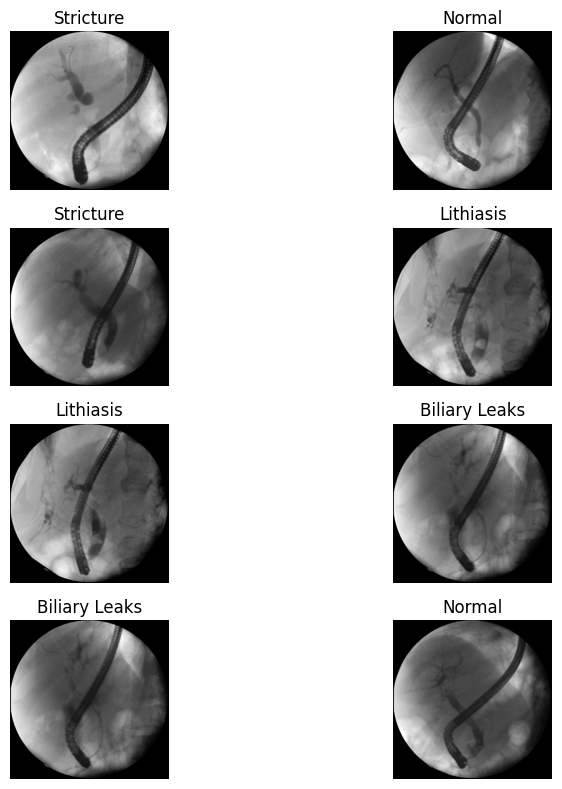

In [10]:
# Visualização rápida de exemplos já transformados parcialmente sem normalização visual complexa
sample_rows = train_df.groupby('label_4class').head(2)
plt.figure(figsize=(10, 8))
for i, (_, row) in enumerate(sample_rows.iterrows(), start=1):
    img = Image.open(row['resolved_path']).convert('RGB').resize((160, 160))
    plt.subplot(len(CLASS_NAMES), 2, i)
    plt.imshow(img, cmap='gray')
    plt.title(row['label_4class'])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [11]:
def build_regnety8gf(num_classes=4):
    try:
        weights = models.RegNet_Y_8GF_Weights.IMAGENET1K_V2
    except AttributeError:
        weights = models.RegNet_Y_8GF_Weights.IMAGENET1K_V1

    model = models.regnet_y_8gf(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.35),
        nn.Linear(in_features, num_classes),
    )
    return model

model = build_regnety8gf(num_classes=len(CLASS_NAMES)).to(device)
print(model.fc)

Sequential(
  (0): Dropout(p=0.35, inplace=False)
  (1): Linear(in_features=2016, out_features=4, bias=True)
)


In [12]:
# Otimizador com LR mais baixo no backbone e mais alto na cabeça de classificação
backbone_params = []
head_params = []
for name, param in model.named_parameters():
    if name.startswith('fc'):
        head_params.append(param)
    else:
        backbone_params.append(param)

optimizer = torch.optim.AdamW(
    [
        {'params': backbone_params, 'lr': LR_BACKBONE},
        {'params': head_params, 'lr': LR_HEAD},
    ],
    weight_decay=WEIGHT_DECAY,
)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

/tmp/ipykernel_42101/2550680648.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [13]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    y_true, y_pred, y_prob = [], [], []

    pbar = tqdm(loader, leave=False)
    for x, y, _ in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = model(x)
                loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

        probs = torch.softmax(logits.detach(), dim=1)
        preds = probs.argmax(dim=1)

        total_loss += loss.item() * x.size(0)
        y_true.extend(y.detach().cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

        pbar.set_description(f"{'train' if is_train else 'eval'} loss={loss.item():.4f}")

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    metrics = {
        'loss': total_loss / len(loader.dataset),
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    return metrics, y_true, y_pred, y_prob


def print_metrics(prefix, metrics):
    print(
        f"{prefix} | loss={metrics['loss']:.4f} | "
        f"acc={metrics['accuracy']:.4f} | bal_acc={metrics['balanced_accuracy']:.4f} | "
        f"macro_f1={metrics['macro_f1']:.4f} | weighted_f1={metrics['weighted_f1']:.4f}"
    )

In [18]:
best_val_f1 = -1
best_epoch = -1
bad_epochs = 0
history = []
best_model_path = MODELS_DIR / 'best_regnety8gf_4class.pt'

for epoch in range(1, EPOCHS + 1):
    print(f'Epoch {epoch}/{EPOCHS}')
    train_metrics, *_ = run_epoch(model, train_loader, optimizer=optimizer)
    val_metrics, *_ = run_epoch(model, val_loader, optimizer=None)
    scheduler.step()

    print_metrics('Train', train_metrics)
    print_metrics('Val  ', val_metrics)

    row = {'epoch': epoch, **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'val_{k}': v for k, v in val_metrics.items()}}
    history.append(row)
    pd.DataFrame(history).to_csv(RESULTS_DIR / 'training_history.csv', index=False)

    if val_metrics['macro_f1'] > best_val_f1:
        best_val_f1 = val_metrics['macro_f1']
        best_epoch = epoch
        bad_epochs = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_names': CLASS_NAMES,
            'class_to_idx': class_to_idx,
            'img_size': IMG_SIZE,
            'epoch': epoch,
            'val_macro_f1': best_val_f1,
        }, best_model_path)
        print(f'Novo melhor modelo guardado: {best_model_path}')
    else:
        bad_epochs += 1
        print(f'Sem melhoria: {bad_epochs}/{PATIENCE}')
        if bad_epochs >= PATIENCE:
            print('Early stopping.')
            break

print(f'Melhor epoch: {best_epoch} | Val macro F1: {best_val_f1:.4f}')

Epoch 1/20


  0%|          | 0/68 [00:00<?, ?it/s]

/tmp/ipykernel_42101/60611063.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


  0%|          | 0/17 [00:00<?, ?it/s]

/tmp/ipykernel_42101/60611063.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


...

  0%|          | 0/68 [00:00<?, ?it/s]

/tmp/ipykernel_42101/60611063.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


  0%|          | 0/17 [00:00<?, ?it/s]

/tmp/ipykernel_42101/60611063.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Train | loss=0.4631 | acc=0.7693 | bal_acc=0.7552 | macro_f1=0.7273 | weighted_f1=0.7355
Val   | loss=1.4885 | acc=0.3284 | bal_acc=0.3881 | macro_f1=0.3203 | weighted_f1=0.2916
Sem melhoria: 3/5
Melhor epoch: 17 | Val macro F1: 0.3485


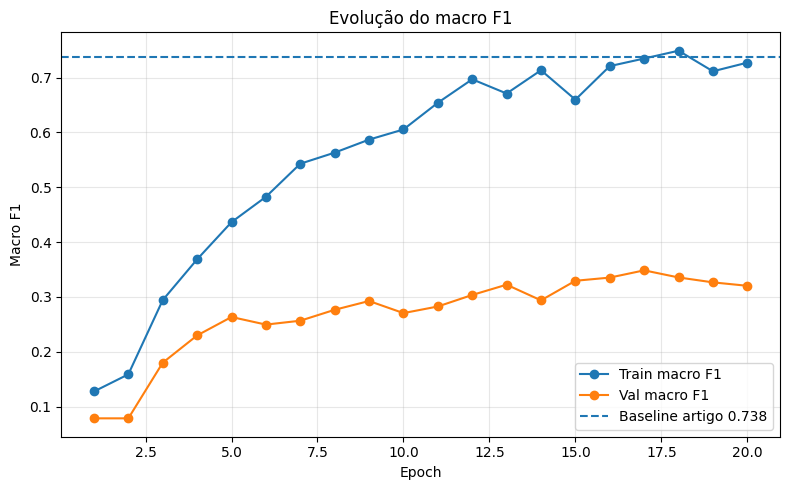

In [19]:
# Curvas de treino
hist = pd.read_csv(RESULTS_DIR / 'training_history.csv')
plt.figure(figsize=(8, 5))
plt.plot(hist['epoch'], hist['train_macro_f1'], marker='o', label='Train macro F1')
plt.plot(hist['epoch'], hist['val_macro_f1'], marker='o', label='Val macro F1')
plt.axhline(BASELINE_MACRO_F1, linestyle='--', label='Baseline artigo 0.738')
plt.xlabel('Epoch')
plt.ylabel('Macro F1')
plt.title('Evolução do macro F1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'macro_f1_curve.png', dpi=200)
plt.show()

In [20]:
# Carregar melhor checkpoint
ckpt = torch.load(best_model_path, map_location=device)
model = build_regnety8gf(num_classes=len(CLASS_NAMES)).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print('Checkpoint carregado:', best_model_path)
print('Epoch:', ckpt['epoch'], '| Val macro F1:', ckpt['val_macro_f1'])

Checkpoint carregado: /mounts/mecd-ap-g5/models/regnety8gf_4class/best_regnety8gf_4class.pt
Epoch: 17 | Val macro F1: 0.34851363523586587


In [22]:
test_metrics, y_true, y_pred, y_prob = run_epoch(model, test_loader, optimizer=None)
print_metrics('Test ', test_metrics)

print('Comparação com baseline do enunciado/artigo:')
print(f"Macro F1 teste: {test_metrics['macro_f1']:.4f}")
print(f"Baseline macro F1: {BASELINE_MACRO_F1:.4f}")
print(f"Diferença: {test_metrics['macro_f1'] - BASELINE_MACRO_F1:+.4f}")

report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report).T
report_df.to_csv(RESULTS_DIR / 'classification_report_test.csv')
display(report_df)

# Métricas multi-classe adicionais, se todas as classes estiverem presentes no teste
try:
    y_true_bin = label_binarize(y_true, classes=list(range(len(CLASS_NAMES))))
    roc_auc_macro = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovr')
    pr_auc_macro = average_precision_score(y_true_bin, y_prob, average='macro')
    print(f'ROC-AUC macro OvR: {roc_auc_macro:.4f}')
    print(f'PR-AUC macro OvR: {pr_auc_macro:.4f}')
except Exception as e:
    print('Não foi possível calcular ROC-AUC/PR-AUC:', repr(e))

  0%|          | 0/14 [00:00<?, ?it/s]

/tmp/ipykernel_42101/60611063.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Test  | loss=1.2245 | acc=0.4906 | bal_acc=0.5244 | macro_f1=0.4403 | weighted_f1=0.4841
Comparação com baseline do enunciado/artigo:
Macro F1 teste: 0.4403
Baseline macro F1: 0.7380
Diferença: -0.2977


,precision,recall,f1-score,support
Biliary Leaks,0.173913,0.333333,0.228571,12.000000
Lithiasis,0.793103,0.239583,0.368000,96.000000
Stricture,0.723077,0.691176,0.706767,68.000000
Normal,0.315789,0.833333,0.458015,36.000000
accuracy,0.490566,0.490566,0.490566,0.490566
macro avg,0.501471,0.524357,0.440338,212.000000
weighted avg,0.654540,0.490566,0.484055,212.000000


ROC-AUC macro OvR: 0.7530
PR-AUC macro OvR: 0.5196


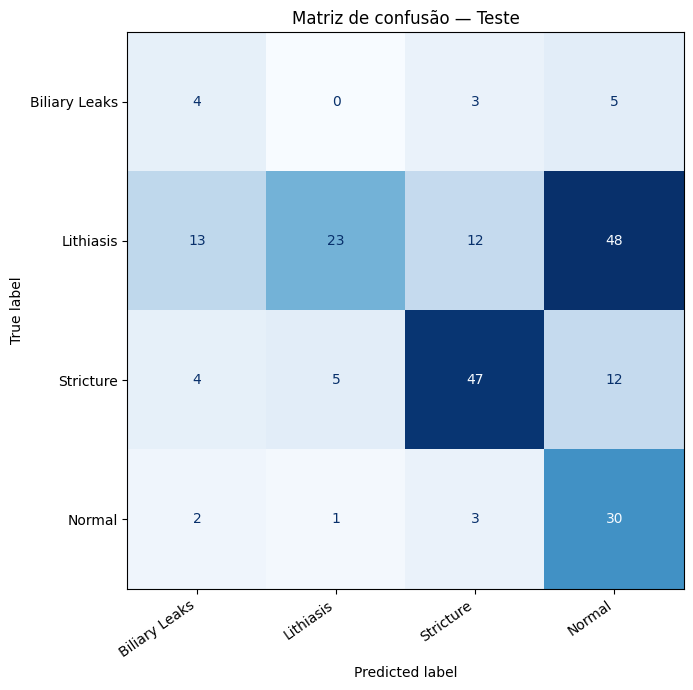

/opt/conda/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,resolved_path,true_label,pred_label,prob_Biliary Leaks,prob_Lithiasis,prob_Stricture,prob_Normal
0,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Normal,Normal,0.140259,0.199219,0.200684,0.459717
1,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,Stricture,0.260010,0.251709,0.350830,0.137573
2,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,Stricture,0.306152,0.242310,0.334473,0.117004
3,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,Stricture,0.231567,0.224487,0.435791,0.108093
4,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,Stricture,0.161621,0.120361,0.661133,0.056854


In [23]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
plt.xticks(rotation=35, ha='right')
plt.title('Matriz de confusão — Teste')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix_test.png', dpi=200)
plt.show()

# Guardar previsões por imagem
pred_df = test_df.copy().reset_index(drop=True)
pred_df['y_true'] = y_true
pred_df['y_pred'] = y_pred
pred_df['true_label'] = [idx_to_class[i] for i in y_true]
pred_df['pred_label'] = [idx_to_class[i] for i in y_pred]
for i, cls in enumerate(CLASS_NAMES):
    pred_df[f'prob_{cls}'] = y_prob[:, i]
pred_df.to_csv(RESULTS_DIR / 'test_predictions.csv', index=False)
display(pred_df[['resolved_path', 'true_label', 'pred_label'] + [f'prob_{c}' for c in CLASS_NAMES]].head())

In [24]:
# Funções auxiliares Grad-CAM

def find_last_conv_module(model):
    last_name, last_module = None, None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_name, last_module = name, module
    print('Última Conv2d usada para Grad-CAM:', last_name)
    return last_module

target_layer = find_last_conv_module(model)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.fwd_handle = target_layer.register_forward_hook(self._forward_hook)
        self.bwd_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        score = logits[:, class_idx].sum()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = torch.nn.functional.interpolate(cam, size=x.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, logits.detach()

    def close(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

def denormalize_tensor(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

cam_generator = GradCAM(model, target_layer)

Última Conv2d usada para Grad-CAM: trunk_output.block4.block4-0.f.c.0


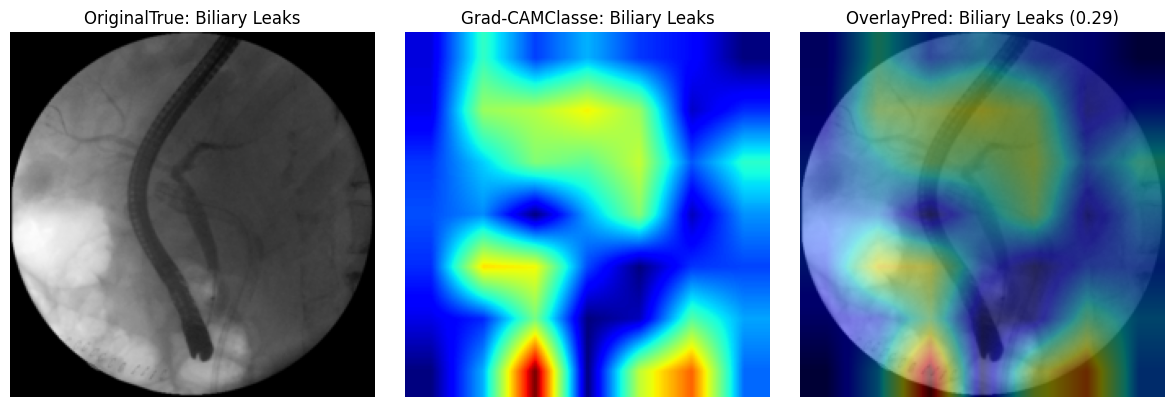

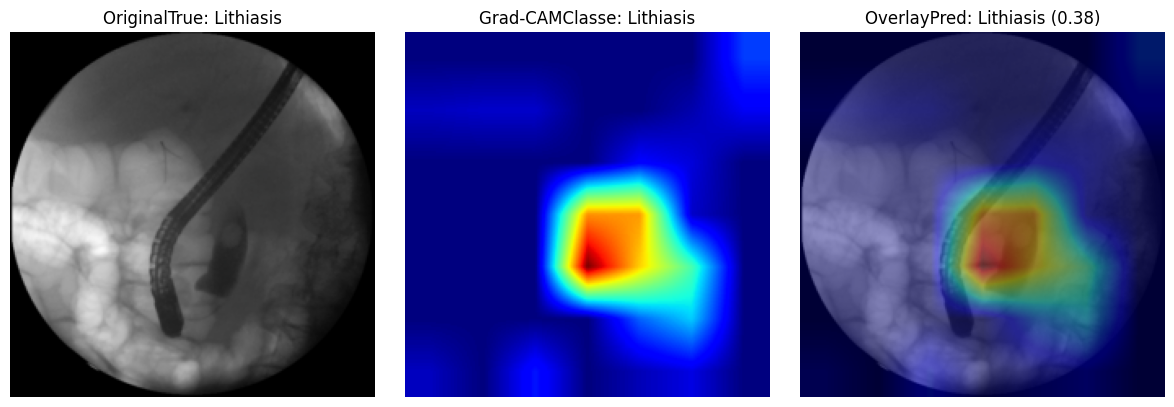

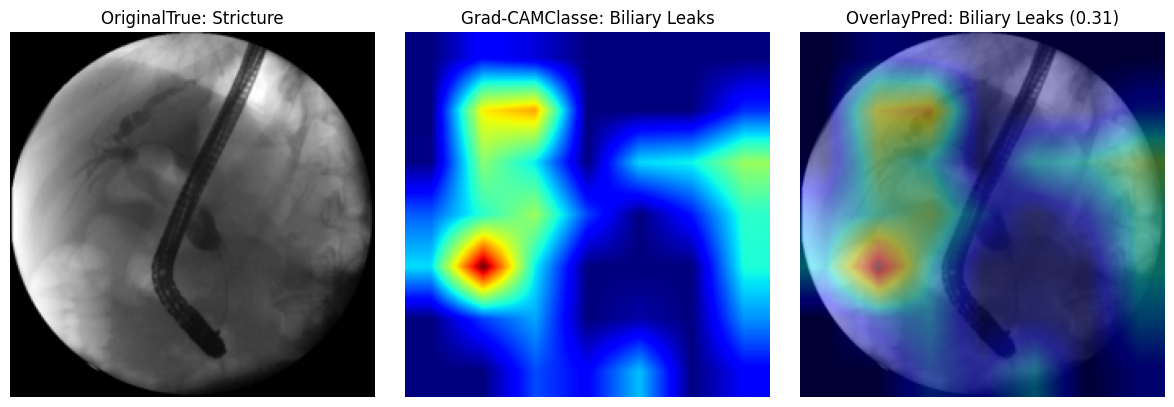

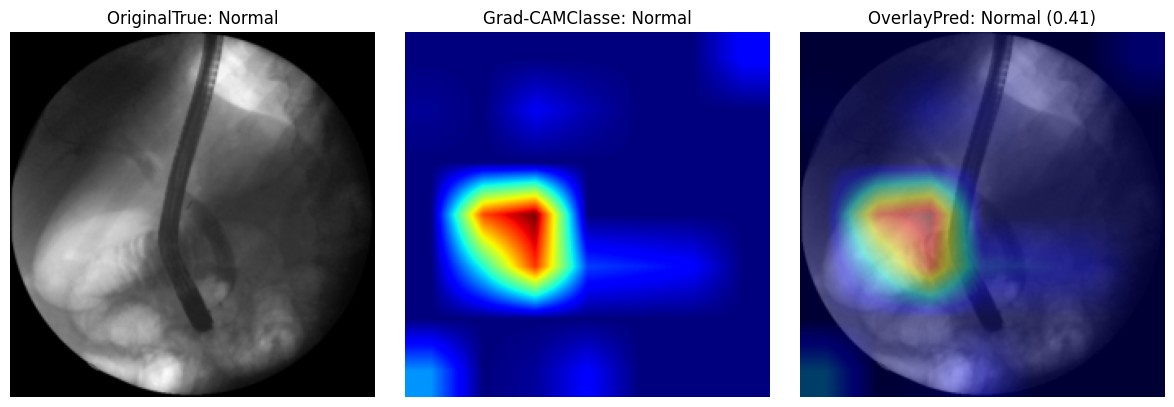

Grad-CAMs guardados em: /mounts/mecd-ap-g5/results/regnety8gf_4class/gradcam_examples


In [26]:
def make_gradcam_figure(row, save_path=None, target='pred'):
    img_pil = Image.open(row['resolved_path']).convert('RGB')
    x = eval_tfms(img_pil).unsqueeze(0).to(device)

    # Primeiro forward para obter previsão
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_idx = int(probs.argmax())

    true_idx = int(row['target'])
    class_idx = pred_idx if target == 'pred' else true_idx

    cam, _ = cam_generator(x, class_idx=class_idx)
    img_vis = denormalize_tensor(x.squeeze(0))

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_vis)
    axes[0].set_title(f"OriginalTrue: {idx_to_class[true_idx]}")
    axes[0].axis('off')

    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title(f"Grad-CAMClasse: {idx_to_class[class_idx]}")
    axes[1].axis('off')

    axes[2].imshow(img_vis)
    axes[2].imshow(cam, cmap='jet', alpha=0.42)
    axes[2].set_title(f"OverlayPred: {idx_to_class[pred_idx]} ({probs[pred_idx]:.2f})")
    axes[2].axis('off')

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

# Gerar uma previsão por classe, preferindo exemplos corretos
cam_dir = RESULTS_DIR / 'gradcam_examples'
cam_dir.mkdir(exist_ok=True)

pred_df = pd.read_csv(RESULTS_DIR / 'test_predictions.csv')
examples = []
for cls in CLASS_NAMES:
    correct = pred_df[(pred_df['true_label'] == cls) & (pred_df['pred_label'] == cls)]
    if len(correct) > 0:
        examples.append(correct.iloc[0])
    else:
        any_cls = pred_df[pred_df['true_label'] == cls]
        if len(any_cls) > 0:
            examples.append(any_cls.iloc[0])

for i, row in enumerate(examples):
    row_dict = row.to_dict()
    # garantir target inteiro a partir do label verdadeiro
    row_dict['target'] = class_to_idx[row_dict['true_label']]
    save_path = cam_dir / f"gradcam_{i}_{row_dict['true_label'].replace(' ', '_')}_pred_{row_dict['pred_label'].replace(' ', '_')}.png"
    make_gradcam_figure(row_dict, save_path=save_path, target='pred')

print('Grad-CAMs guardados em:', cam_dir)

In [27]:
summary = {
    'model': 'RegNetY-8GF pretrained on ImageNet',
    'num_classes': len(CLASS_NAMES),
    'classes': CLASS_NAMES,
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs_run': int(best_epoch),
    'best_val_macro_f1': float(best_val_f1),
    'test_macro_f1': float(test_metrics['macro_f1']),
    'test_balanced_accuracy': float(test_metrics['balanced_accuracy']),
    'test_accuracy': float(test_metrics['accuracy']),
    'baseline_macro_f1': BASELINE_MACRO_F1,
    'delta_vs_baseline': float(test_metrics['macro_f1'] - BASELINE_MACRO_F1),
    'best_model_path': str(best_model_path),
    'results_dir': str(RESULTS_DIR),
}

with open(RESULTS_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

summary

{'model': 'RegNetY-8GF pretrained on ImageNet',
 'num_classes': 4,
 'classes': ['Biliary Leaks', 'Lithiasis', 'Stricture', 'Normal'],
 'img_size': 224,
 'batch_size': 16,
 'epochs_run': 17,
 'best_val_macro_f1': 0.34851363523586587,
 'test_macro_f1': 0.44033840326005846,
 'test_balanced_accuracy': 0.5243566176470589,
 'test_accuracy': 0.49056603773584906,
 'baseline_macro_f1': 0.738,
 'delta_vs_baseline': -0.2976615967399415,
 'best_model_path': '/mounts/mecd-ap-g5/models/regnety8gf_4class/best_regnety8gf_4class.pt',
 'results_dir': '/mounts/mecd-ap-g5/results/regnety8gf_4class'}